In [ ]:
import numpy as np
def cosine_similarity(a,b):
  return np.dot(a,b) / (np.linalg.norm(a) * np.linalg.norm(b))
good = np.array([0.82, 0.41, 0.10])
great = np.array([0.79, 0.38, 0.12])
bad = np.array([-0.71, 0.12, -0.05])
print(f'good vs great : {cosine_similarity(good, great):.3f}')
print(f'good vs bad : {cosine_similarity(good, bad):.3f}')
print(f'great vs bad : {cosine_similarity(great, bad):.3f}')
print(f'bad vs bad : {cosine_similarity(bad, bad):.3f}')

good vs great : 1.000
good vs bad : -0.808
great vs bad : -0.816
bad vs bad : 1.000


In [ ]:
!pip install gensim
from gensim.models import Word2Vec
# A small corpus — in practice use millions of sentences
sentences = [
'the king ruled the kingdom wisely',
'the queen ruled the land gracefully',
'the prince will become king one day',
'a man walked into the palace',
'a woman walked into the palace',
'the dog barked loudly in the garden',
'the puppy played happily in the garden',
]
# Tokenise each sentence into a list of words
tokenised = [s.split() for s in sentences]
# Train Word2Vec
# vector_size=50: each word gets a 50-number vector
# window=3: look 3 words left and right for context
# sg=1: use Skip-gram (sg=0 for CBOW)
# epochs=200: pass through the data 200 times
model = Word2Vec(sentences=tokenised, vector_size=50,
window=3, min_count=1, sg=1, epochs=200)
# Find top-3 most similar words to 'king'
print(model.wv.most_similar('king', topn=3))
# [('queen', 0.91), ('prince', 0.88), ('kingdom', 0.85)]
# The famous analogy: king - man + woman
result = model.wv.most_similar(
positive=['dog', 'puppy'], # add these
negative=['man'], # subtract this
topn=2
)
print('king - man + woman =', result[1][0]) # 'queen'


[('kingdom', 0.40141454339027405), ('played', 0.38476690649986267), ('in', 0.38395753502845764)]
king - man + woman = the


In [2]:
import sys
!{sys.executable} -m pip install gensim
# Step 0: Download GloVe vectors
# https://nlp.stanford.edu/data/glove.6B.zip (about 800 MB)
# Extract and you get: glove.6B.50d.txt, glove.6B.100d.txt, etc.
!wget --no-check-certificate https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

# Step 1: Convert GloVe format to Word2Vec format (one-time step)

from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')

# Step 2: Load the converted file
from gensim.models import KeyedVectors
glove = KeyedVectors.load_word2vec_format(
'glove.6B.100d.w2v.txt', binary=False
)

# Takes ~30 seconds; 400,000 words x 100 dimensions


# Step 3: Use it!
# --- Find top-5 most similar words ---
print(glove.most_similar('bollywood', topn=5))


# [('cinema', 0.82), ('films', 0.79), ('actors', 0.77), ...]
# --- Test analogy ---
res = glove.most_similar(positive=['paris','tamilnadu'], negative=['france'],
topn=1)
print('paris - france + india =', res[0][0]) # hopefully 'delhi'!
# --- Cosine similarity between two words ---
print(glove.similarity('dog', 'puppy')) # ~0.81
print(glove.similarity('cat', 'cricket')) # ~0.12 (unrelated)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.8 MB/s eta 0:00:00
--2026-06-11 07:54:22--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-11 07:54:22--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  4.70MB/s    in 2m 43s  

2026-06-11 07:57:05 (5.03 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



/tmp/ipykernel_16707/1006050496.py:12: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')


[('malayalam', 0.6783681511878967), ('film', 0.660624086856842), ('films', 0.6603192090988159), ('hindi', 0.6582645773887634), ('movie', 0.6446917653083801)]
paris - france + india = bhubaneswar
0.7236376
0.1919626


In [3]:
import gensim.downloader as api
fy = api.load('fasttext-wiki-news-subwords-300')
print(fy.most_similar('bollywood', topn=3))

[==================================================] 100.0% 958.5/958.4MB downloaded
[('tollywood', 0.7688723802566528), ('kollywood', 0.7686912417411804), ('hollywood', 0.7619378566741943)]


In [4]:
import gensim.downloader as api
glove_sm = api.load('glove-wiki-gigaword-50')
print(glove_sm.most_similar('bollywood', topn=3))

[==================================================] 100.0% 66.0/66.0MB downloaded
[('malayalam', 0.7608863115310669), ('films', 0.7456727623939514), ('hindi', 0.7311806678771973)]


Missing words: {'rama chandra', 'shravanthparis'}
Vector matrix shape: (15, 100)


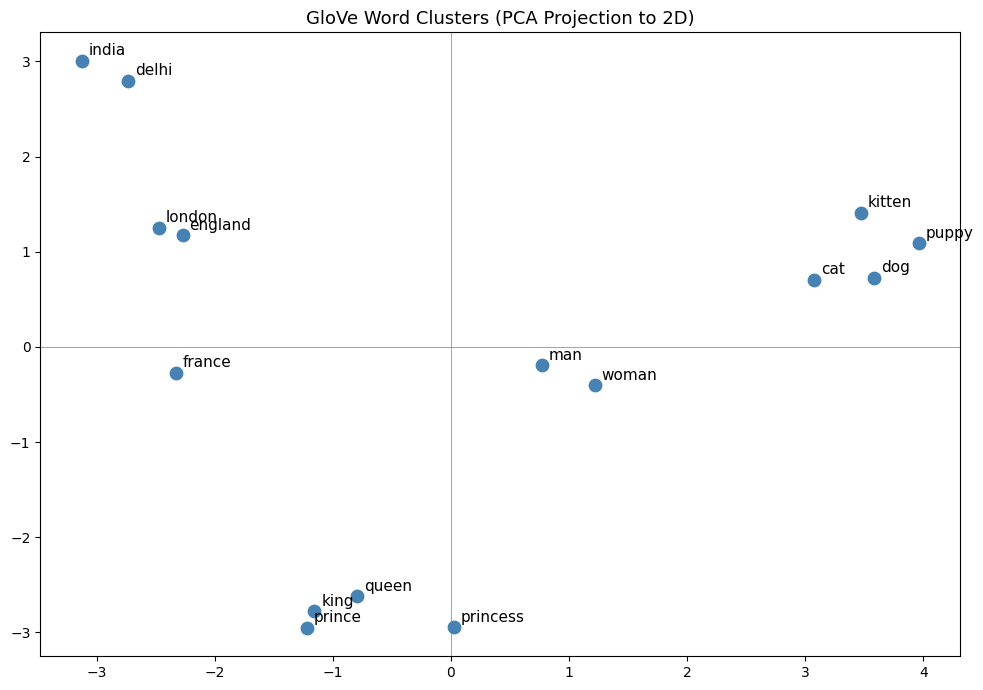

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import KeyedVectors

# Assuming you already loaded GloVe:
# glove = KeyedVectors.load_word2vec_format(
#     'glove.6B.100d.w2v.txt',
#     binary=False
# )

# Words to visualize
words = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess',
    'dog', 'puppy', 'cat', 'kitten','rama chandra','shravanth'
    'paris', 'france', 'delhi', 'india', 'london', 'england'
]

# Keep only words that exist in the model
valid_words = [w for w in words if w in glove.key_to_index]

missing_words = set(words) - set(valid_words)
if missing_words:
    print("Missing words:", missing_words)

# Extract vectors
vectors = np.array([glove[w] for w in valid_words])

print("Vector matrix shape:", vectors.shape)

# Reduce dimensions from 100D -> 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=80,
    color='steelblue',
    zorder=3
)

# Add labels
for i, word in enumerate(valid_words):
    ax.annotate(
        word,
        (coords[i, 0], coords[i, 1]),
        fontsize=11,
        xytext=(5, 4),
        textcoords='offset points'
    )

ax.set_title(
    'GloVe Word Clusters (PCA Projection to 2D)',
    fontsize=13
)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('word_clusters.png', dpi=150)
plt.show()

#Lab — Movie Description Similarity

Build a mini recommendation engine for Bollywood & Hollywood movies.

Datasets used: manually creating a dataset.

**Steps**

Step1: Creating a movie dataset.

Step2: Building vectors and find similar movies.

Step3:  Visualising movie clusters

                         title
0  Dilwale Dulhania Le Jayenge
1                       Lagaan
2                       Dangal
3                     3 Idiots
4               Dil Chahta Hai
5                      Titanic
6                        Rocky
7            Good Will Hunting
8             Chariots of Fire
9               Before Sunrise
QUERY: An underdog athlete trains hard and wins against all expectations
           title  similarity
           Rocky       0.927
          Dangal       0.926
Chariots of Fire       0.911

QUERY: Two people fall in love while travelling across Europe
                      title  similarity
             Before Sunrise       0.955
Dilwale Dulhania Le Jayenge       0.935
                    Titanic       0.905


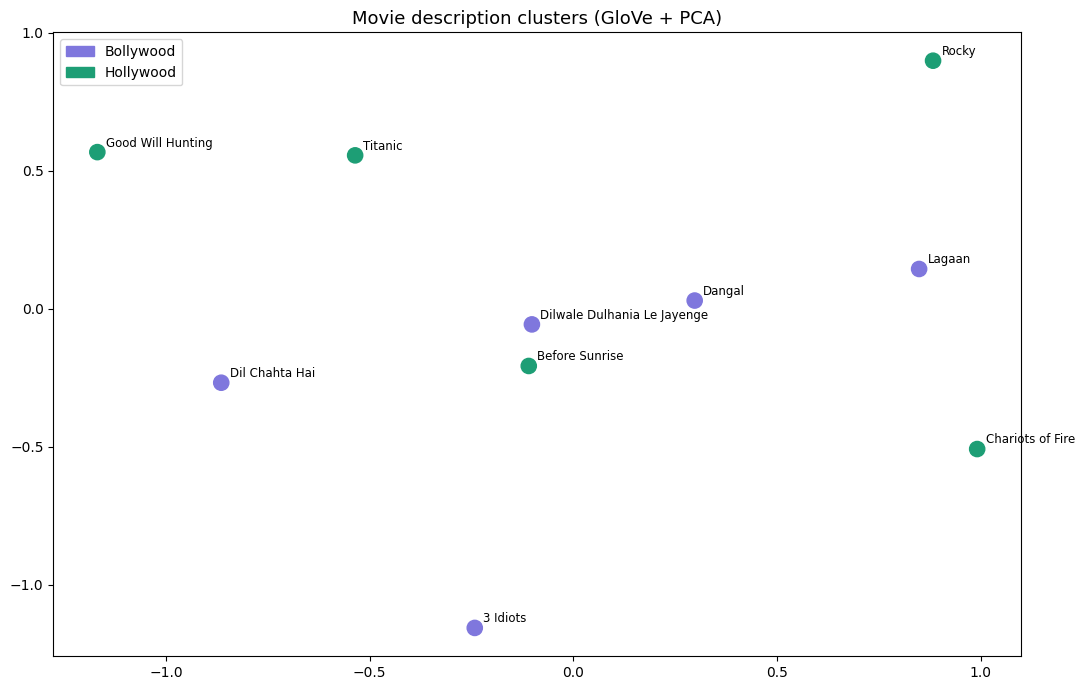

In [12]:
#Step1

import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
# Load pre-trained GloVe (100 dimensions)
glove = KeyedVectors.load_word2vec_format('glove.6B.100d.w2v.txt',
binary=False)
# Our movie dataset — Bollywood + Hollywood
movies = [
# Bollywood
{'title':'Dilwale Dulhania Le Jayenge',
'desc':'A young man follows the woman he loves to India after they fall inlove in Europe'},
{'title':'Lagaan',
'desc':'Villagers challenge British colonisers to a cricket match to avoipaying heavy taxes'},
{'title':'Dangal',
'desc':'A father trains his daughters to become world class wrestlers against all odds'},
{'title':'3 Idiots',
'desc':'Three college friends question the pressure of engineering education in India'},
{'title':'Dil Chahta Hai',
'desc':'Three best friends navigate love relationships and life after graduation'},
# Hollywood
{'title':'Titanic',
'desc':'A wealthy girl and a poor artist fall in love on a doomed ocean liner'},
{'title':'Rocky',
'desc':'An underdog boxer trains relentlessly for a shot at the world heavyweight champion'},
{'title':'Good Will Hunting',
'desc':'A genius janitor from Boston works through emotional trauma with a therapist'},
{'title':'Chariots of Fire',
'desc':'Two British athletes train and compete for glory in the 1924 Olympic Games'},
{'title':'Before Sunrise',
'desc':'Two strangers meet on a train in Europe and spend one romantic night in Vienna'},
]
df = pd.DataFrame(movies)
print(df[['title']].to_string())

#Step2

from sklearn.metrics.pairwise import cosine_similarity
def sentence_vector(text, model, dim=100):
    tokens = text.lower().split()
    vecs = [model[t] for t in tokens if t in model]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)
# Build vector for each movie description
df['vector'] = df['desc'].apply(lambda d: sentence_vector(d, glove))
# Stack all vectors into a matrix (10 x 100)
V = np.stack(df['vector'].values)
# Function: given a query description, find top-N most similar movies
def find_similar(query_desc, df, top_n=3):
# Vectorise the query using the same sentence_vector function
  qvec = sentence_vector(query_desc, glove).reshape(1, -1)
# Compute cosine similarity between query and every movie
  sims = cosine_similarity(qvec, V)[0] # returns array of 10 scores
# Get indices sorted from highest to lowest similarity
  idx = np.argsort(sims)[::-1][:top_n]
  result = df.iloc[idx][['title']].copy()
  result['similarity'] = np.round(sims[idx], 3)
  return result
# --- Query 1: underdog sports story ---
q1 = 'An underdog athlete trains hard and wins against all expectations'
print('QUERY:', q1)
print(find_similar(q1, df).to_string(index=False))
# Expected: Dangal, Rocky, Chariots of Fire near the top
# --- Query 2: romance in Europe ---
q2 = 'Two people fall in love while travelling across Europe'
print('\nQUERY:', q2)
print(find_similar(q2, df).to_string(index=False))
# Expected: DDLJ, Before Sunrise, Titanic near the top

#Step3

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# Reduce 100-D vectors to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(V) # shape: (10, 2)
# Colour Bollywood purple, Hollywood teal
colours = ['#7F77DD']*5 + ['#1D9E75']*5
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(coords[:,0], coords[:,1], c=colours, s=120, zorder=3)
# Label each point with the movie title
for i, row in df.iterrows():
  ax.annotate(row['title'], coords[i], fontsize=8.5,
xytext=(6, 4), textcoords='offset points')
# Add legend
import matplotlib.patches as mpatches
ax.legend(handles=[
mpatches.Patch(color='#7F77DD', label='Bollywood'),
mpatches.Patch(color='#1D9E75', label='Hollywood'),
], fontsize=10)
ax.set_title('Movie description clusters (GloVe + PCA)', fontsize=13)
plt.tight_layout()
plt.savefig('movie_clusters.png', dpi=150)
plt.show()
# Action movies (Lagaan, Rocky, Dangal, Chariots) should cluster together
# Romance movies (DDLJ, Titanic, Before Sunrise) should be in another cluster